   Year        T2M       RH2M  PRECTOTCORR      NDVI     Yield
0  2015  26.546466  46.651151       737.89  0.399717  2.569311
1  2016  26.391230  49.130410      1050.69  0.382146  2.604871
2  2017  26.231397  51.598548      1128.51  0.376525  2.636773
3  2018  25.947151  52.359288      1381.52  0.403998  2.758699
4  2019  25.403644  58.926575      1300.60  0.376034  2.764556

MODEL PERFORMANCE
MAE  : 0.06088883651531507
RMSE : 0.06290844380784072
R2   : 0.9085931869208568


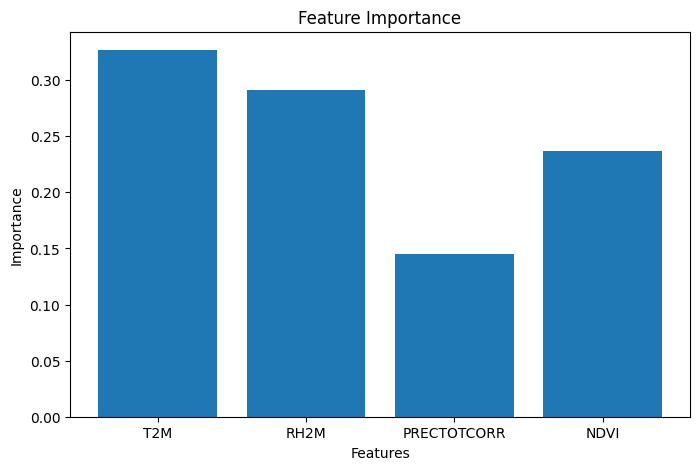

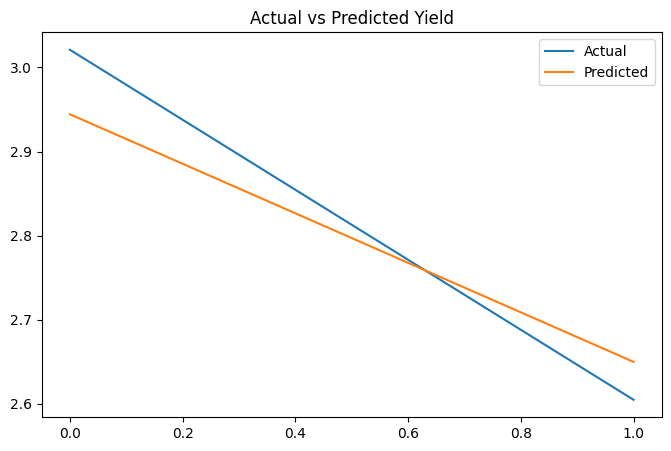

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ======================================
# LOAD DATASET
# ======================================

df = pd.read_csv("../datasets/final_dataset.csv")

print(df.head())


# ======================================
# FEATURES & TARGET
# ======================================

X = df[['T2M', 'RH2M', 'PRECTOTCORR', 'NDVI']]

y = df['Yield']


# ======================================
# TRAIN TEST SPLIT
# ======================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# ======================================
# RANDOM FOREST MODEL
# ======================================

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)


# ======================================
# PREDICTIONS
# ======================================

y_pred = model.predict(X_test)


# ======================================
# EVALUATION
# ======================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = mse ** 0.5

r2 = r2_score(y_test, y_pred)

print("\nMODEL PERFORMANCE")
print(f"MAE  : {mae}")
print(f"RMSE : {rmse}")
print(f"R2   : {r2}")


# ======================================
# FEATURE IMPORTANCE
# ======================================

importance = model.feature_importances_

features = X.columns

plt.figure(figsize=(8,5))

plt.bar(features, importance)

plt.title("Feature Importance")

plt.xlabel("Features")

plt.ylabel("Importance")

plt.show()


# ======================================
# ACTUAL VS PREDICTED
# ======================================

plt.figure(figsize=(8,5))

plt.plot(y_test.values, label='Actual')

plt.plot(y_pred, label='Predicted')

plt.legend()

plt.title("Actual vs Predicted Yield")

plt.show()